## Import Libraries

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
import joblib

## Load Dataset

In [110]:
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


## Data Exploration

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [112]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [113]:
df.shape

(4340, 8)

In [114]:
df.duplicated().sum()

np.int64(763)

## Data Cleaning

In [115]:
df.drop_duplicates(inplace=True)

In [116]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics

In [117]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,3577.0,2012.962538,4.251759,1992.0,2010.0,2013.0,2016.0,2020.0
selling_price,3577.0,473912.542074,509301.809816,20000.0,200000.0,350000.0,600000.0,8900000.0
km_driven,3577.0,69250.545709,47579.940016,1.0,36000.0,60000.0,90000.0,806599.0


In [118]:
df.skew(numeric_only=True)

year            -0.786122
selling_price    5.453918
km_driven        2.548522
dtype: float64

In [119]:
df.kurt(numeric_only=True)

year              0.621862
selling_price    53.664109
km_driven        22.206465
dtype: float64

## Exploratory Data Analysis (EDA)

In [120]:
numerical_columns = df.select_dtypes(include=['int64']).columns

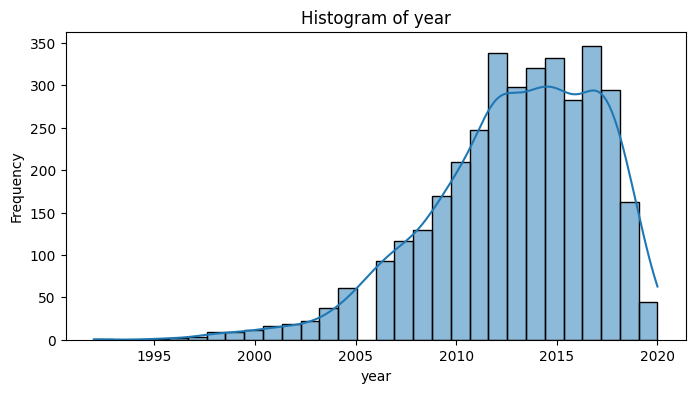

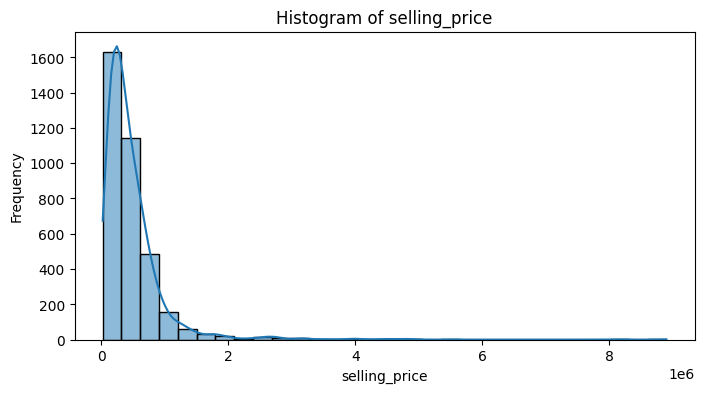

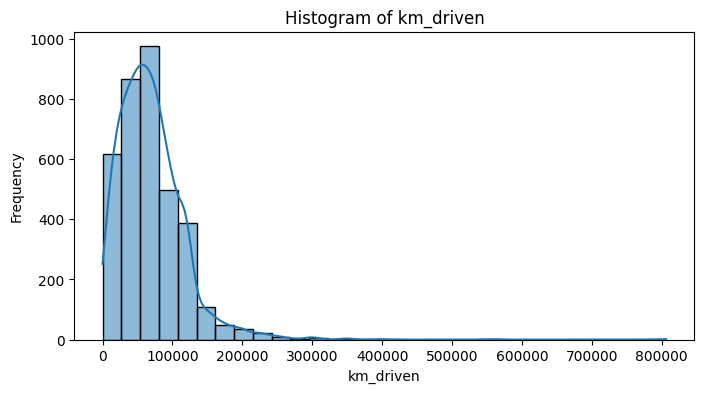

In [121]:
for column in numerical_columns:

    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

<u>Distribution Analysis:</u>

- **Year:** Most vehicles were manufactured between **2010 and 2018**, indicating that the dataset mainly consists of relatively recent cars. Only a few older vehicles are present.

- **Selling Price:** The distribution is **highly right-skewed**, with most vehicles having relatively lower selling prices and a small number of premium vehicles with significantly higher prices.

- **KM Driven:** The distribution is also **right-skewed**. Most vehicles have moderate mileage, while a few vehicles have exceptionally high kilometers driven.

Overall, the distribution plots indicate that the numerical features are not normally distributed and contain skewness, particularly for **Selling Price** and **KM Driven**.

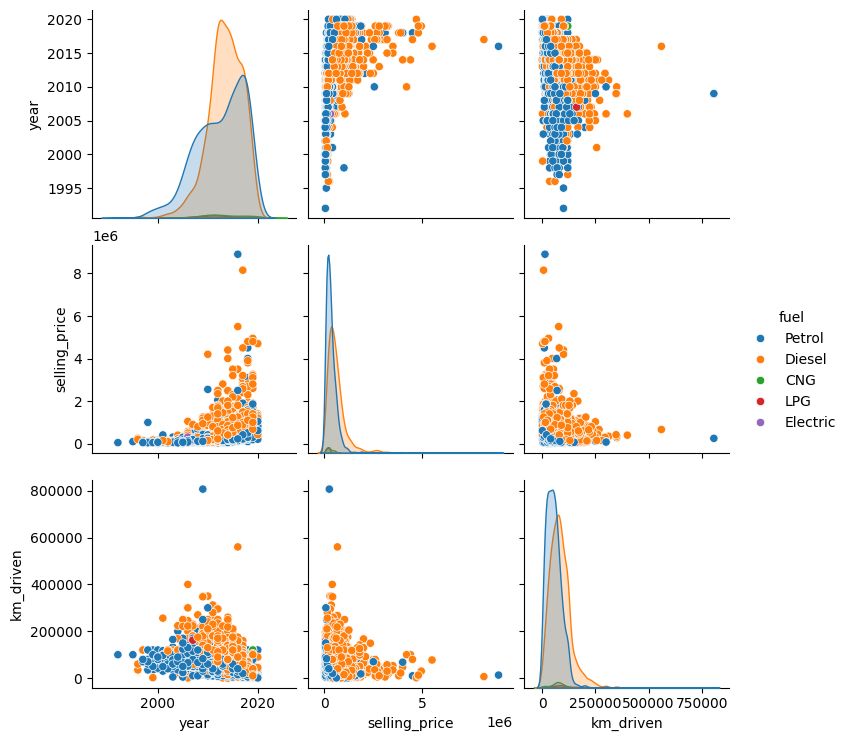

In [122]:
sns.pairplot(df,hue='fuel')

<u>Pair Plot Analysis:</u>

Most vehicles in the dataset were manufactured between **2010 and 2018**, indicating that the dataset mainly contains relatively newer cars.
- **Selling Price** generally increases with newer manufacturing years, suggesting that newer vehicles tend to have higher market values.
- **Selling Price** tends to decrease as **Kilometers Driven** increases, indicating a negative relationship between vehicle usage and resale value.
- The distributions of **Selling Price** and **Kilometers Driven** are positively skewed due to the presence of a few high-value observations.
- Diesel and Petrol vehicles represent the majority of the dataset, while CNG, LPG, and Electric vehicles appear less frequently.
- A few extreme observations are visible in both **Selling Price** and **Kilometers Driven**, which correspond to premium vehicles or heavily used cars.

Overall, the pair plot provides valuable insights into the relationships between numerical variables and highlights patterns that may influence the prediction of used car selling prices.

## Correlation Heatmap

<Axes: >

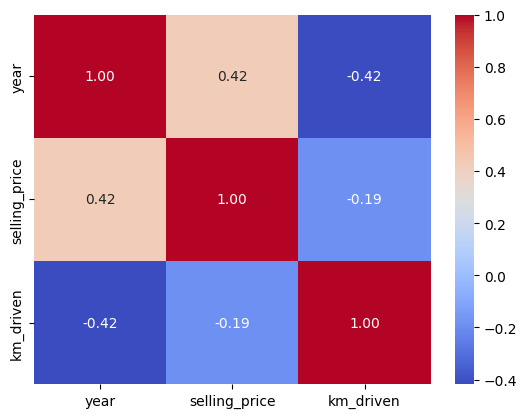

In [123]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm', fmt='.2f')

<u>Correlation Heatmap:</u>

**Year** has a **moderate positive correlation (0.42)** with **Selling Price**, indicating that newer vehicles generally have higher selling prices.

- **Year** has a **moderate negative correlation (-0.42)** with **KM Driven**, suggesting that newer vehicles tend to have lower mileage.

- **Selling Price** has a **weak negative correlation (-0.19)** with **KM Driven**, meaning that vehicles with higher mileage generally have slightly lower selling prices.

- No pair of numerical features shows a very strong correlation (|r| > 0.8), indicating that severe multicollinearity is not present in the dataset.

Overall, the correlation analysis suggests that **vehicle age (year)** and **kilometers driven** influence the selling price, although their relationships are moderate rather than strong.

## Outlier Detection

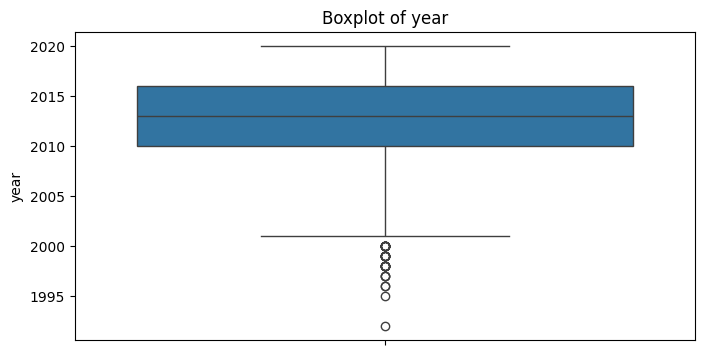

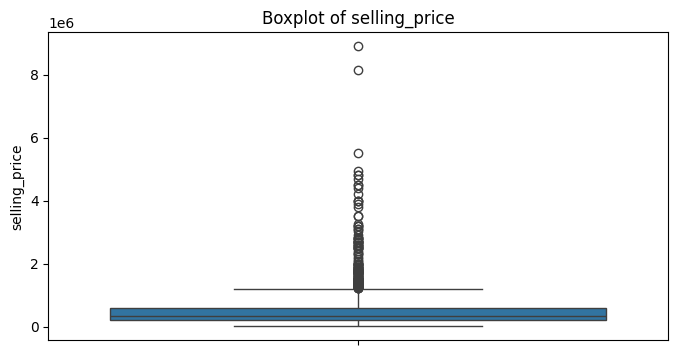

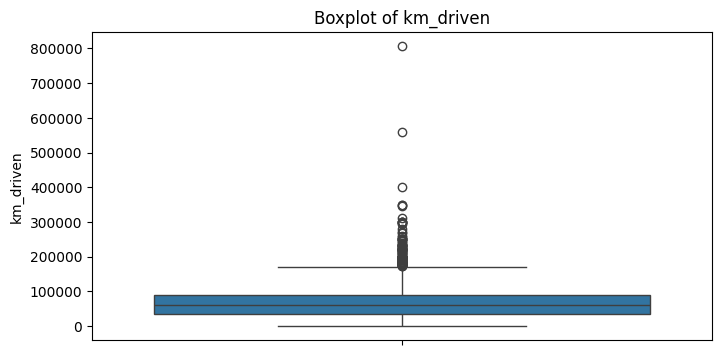

In [124]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

<u>Boxplot Analysis:</u>

- The **Year** feature contains a few outliers representing older vehicles manufactured before the majority of the dataset.
- The **Selling Price** feature is positively skewed with several high-value outliers, indicating the presence of premium and luxury vehicles.
- The **KM Driven** feature also contains a number of high-mileage vehicles that appear as outliers.
- These outliers are likely to be genuine observations rather than data entry errors, as they represent real-world variations in vehicle age, price, and usage.

Therefore, the outliers were identified using boxplots and further examined using the Interquartile Range (IQR) method before making any preprocessing decisions.

In [125]:
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers")

year: 37 outliers
selling_price: 170 outliers
km_driven: 106 outliers


<u>Outlier Detection Using the IQR Method:</u>

To quantify the outliers identified in the boxplots, the Interquartile Range (IQR) method was applied to all numerical features.

The analysis detected:

- **Year:** 37 outliers
- **Selling Price:** 170 outliers
- **KM Driven:** 106 outliers

Since these observations represent genuine vehicle characteristics rather than incorrect data, they were retained for model training instead of being removed.

In [126]:
outliers

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
32,Audi Q5 2.0 TDI,2011,1190000,175900,Diesel,Dealer,Automatic,First Owner
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,Diesel,Individual,Manual,Second Owner
70,Toyota Corolla Altis Diesel D4DG,2011,350000,230000,Diesel,Individual,Manual,First Owner
159,Chevrolet Enjoy 1.3 TCDi LS 8,2015,300000,175000,Diesel,Individual,Manual,First Owner
197,Mahindra Xylo E4,2009,229999,230000,Diesel,Individual,Manual,Third Owner
...,...,...,...,...,...,...,...,...
4208,Toyota Qualis FS B3,2001,150000,256000,Diesel,Dealer,Manual,First Owner
4231,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2011,800000,230000,Diesel,Individual,Manual,First Owner
4255,Mahindra XUV500 W8 2WD,2014,650000,218000,Diesel,Individual,Manual,Second Owner
4286,Fiat Punto 1.3 Emotion,2010,130000,210000,Diesel,Individual,Manual,Second Owner


## Feature Engineering

In [127]:
current_year = 2025

df['car_age'] = current_year - df['year']

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,18
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,18
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,13
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,8
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,11


In [128]:
df.drop('year',axis=1,inplace=True)

In [129]:
df['brand'] = df['name'].str.split().str[0]

df.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,Maruti 800 AC,60000,70000,Petrol,Individual,Manual,First Owner,18,Maruti
1,Maruti Wagon R LXI Minor,135000,50000,Petrol,Individual,Manual,First Owner,18,Maruti
2,Hyundai Verna 1.6 SX,600000,100000,Diesel,Individual,Manual,First Owner,13,Hyundai
3,Datsun RediGO T Option,250000,46000,Petrol,Individual,Manual,First Owner,8,Datsun
4,Honda Amaze VX i-DTEC,450000,141000,Diesel,Individual,Manual,Second Owner,11,Honda


In [130]:
X = df.drop('selling_price',axis=1)
y = df['selling_price']

In [131]:
X

,name,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,Maruti 800 AC,70000,Petrol,Individual,Manual,First Owner,18,Maruti
1,Maruti Wagon R LXI Minor,50000,Petrol,Individual,Manual,First Owner,18,Maruti
2,Hyundai Verna 1.6 SX,100000,Diesel,Individual,Manual,First Owner,13,Hyundai
3,Datsun RediGO T Option,46000,Petrol,Individual,Manual,First Owner,8,Datsun
4,Honda Amaze VX i-DTEC,141000,Diesel,Individual,Manual,Second Owner,11,Honda
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),80000,Diesel,Individual,Manual,Second Owner,11,Hyundai
4336,Hyundai i20 Magna 1.4 CRDi,80000,Diesel,Individual,Manual,Second Owner,11,Hyundai
4337,Maruti 800 AC BSIII,83000,Petrol,Individual,Manual,Second Owner,16,Maruti
4338,Hyundai Creta 1.6 CRDi SX Option,90000,Diesel,Individual,Manual,First Owner,9,Hyundai


In [132]:
y 

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 3577, dtype: int64

## Feature Encoding and Preprocessing

In [133]:
df['brand'] = df['name'].str.split().str[0]

In [134]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64']).columns.tolist()

preprocessor = ColumnTransformer(

    transformers=[

        ('onehot', OneHotEncoder(drop='first',handle_unknown='ignore'), categorical_features),
        ('numerical_features', StandardScaler(), numerical_features)

    ]
    
)

## Train-Test Split

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model Building

In [136]:
models = {

    'LinearRegression' : Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),

    'DecisionTreeRegressor' : Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ]),

    'RandomForestRegressor' : Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ]),

    'GradientBoostingRegressor' : Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(random_state=42))
    ]),

    'KNeighborsRegressor' : Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', KNeighborsRegressor())
    ]),

    'XGBRegressor' : Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(random_state=42))
    ])
    
}

## Model Evaluation

In [137]:
warnings.filterwarnings("ignore", category=UserWarning)

In [138]:
results = []

for name, pipeline in models.items():

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({

        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2

    })

results_df = pd.DataFrame(results)

results_df.sort_values(by='R2 Score', ascending=False)

print(results_df.round(4))

                       Model          MAE           MSE         RMSE  R2 Score
0           LinearRegression  131816.9472  1.214311e+11  348469.7104    0.6230
1      DecisionTreeRegressor  160029.8932  1.443664e+11  379955.7647    0.5518
2      RandomForestRegressor  136036.6678  1.294380e+11  359774.9458    0.5982
3  GradientBoostingRegressor  157558.4672  1.354662e+11  368057.3290    0.5795
4        KNeighborsRegressor  137086.5902  1.297160e+11  360161.0798    0.5973
5               XGBRegressor  138662.9062  1.294390e+11  359776.3629    0.5982


## Cross Validation

In [139]:
best_model = models['LinearRegression']

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean R2 Score:", cv_scores.mean())

Cross-Validation R2 Scores: [0.59399052 0.81695624 0.70640149 0.66868466 0.62270512]
Mean R2 Score: 0.6817476052812182


## Feature Coefficient

In [140]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

feature_names = [
    feature.replace("onehot__", "")
           .replace("numerical_features__", "")
    for feature in feature_names
]

coefficients = best_model.named_steps['regressor'].coef_

feature_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_coefficients = feature_coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

feature_coefficients.head(10)

,Feature,Coefficient
20,name_Audi RS7 2015-2019 Sportback Performance,6.677209e+06
957,name_Mercedes-Benz GL-Class 350 CDI Blue Effic...,2.708834e+06
33,name_BMW X5 xDrive 30d xLine,2.587498e+06
1327,brand_Land,2.353817e+06
1302,name_Volvo XC 90 D5 Inscription BSIV,2.242042e+06
8,name_Audi A5 Sportback,2.232427e+06
28,name_BMW 7 Series Signature 730Ld,1.816187e+06
1209,name_Toyota Fortuner 2.8 2WD AT BSIV,1.802409e+06
156,name_Ford Endeavour 2.2 Titanium AT 4X2,1.639194e+06
164,name_Ford Endeavour Titanium Plus 4X4,1.571422e+06


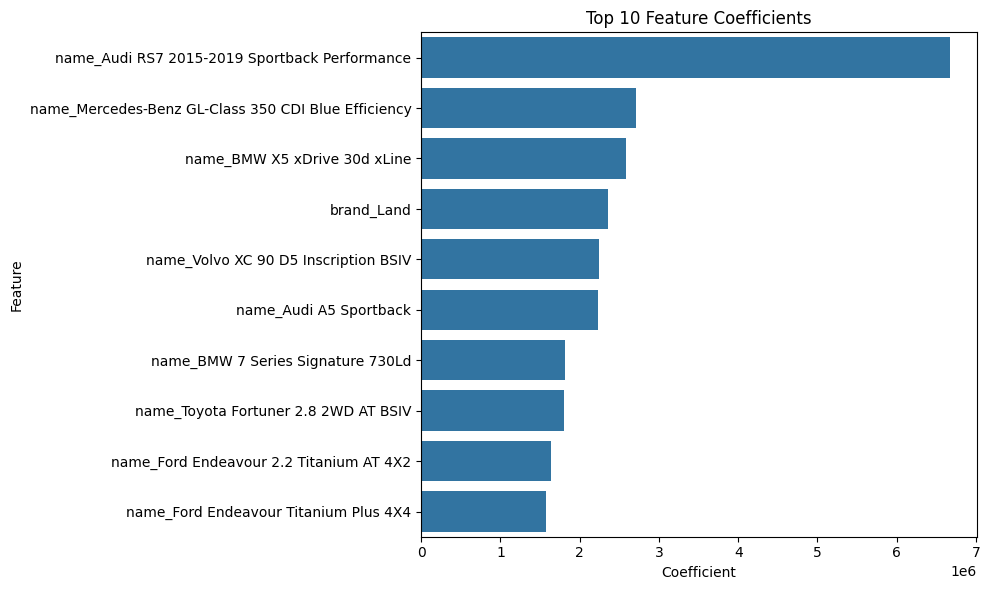

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_coefficients.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Feature Coefficients")
plt.tight_layout()
plt.show()

<u>Feature Coefficient Analysis:</u>

The chart above shows the **Top 10 Feature Coefficients** used by the Linear Regression model.

- Features with **higher positive coefficients** have a stronger positive impact on the predicted selling price.
- The feature **`name_Audi RS7 2015-2019 Sportback Performance`** has the highest coefficient, indicating that this car model contributes the most to increasing the predicted price.
- Other premium car models, such as **Mercedes-Benz GL-Class**, **BMW X5**, **Volvo XC90**, and **Audi A5**, also have significant positive effects on the selling price.
- The feature **`brand_Land`** also appears among the top features, showing that the Land Rover brand is strongly associated with higher vehicle prices.
- Overall, luxury brands and high-end vehicle models have the greatest influence on the model's price prediction.

## Save Model

In [142]:
joblib.dump(best_model, 'used_car_price_prediction_model.pkl')

['used_car_price_prediction_model.pkl']

In [143]:
loaded_model = joblib.load('used_car_price_prediction_model.pkl')

prediction = loaded_model.predict(X_test.iloc[[0]])

print("Predicted Selling Price:", prediction[0])
print("Actual Selling Price:", y_test.iloc[0])

Predicted Selling Price: 358791.5598248013
Actual Selling Price: 270000


In [144]:
df.to_csv('used_cars_price_prediction_cleaned_data.csv', index=False)

## Conclusion

- This project successfully developed a machine learning model to predict the selling price of used cars using the **CarDekho Vehicle Dataset**.
- Data preprocessing included handling missing values, duplicate checking, outlier detection, feature engineering, and categorical feature encoding.
- Exploratory Data Analysis (EDA) was performed to understand the distribution of features and their relationships with the target variable.
- Multiple regression models were trained and compared, including **Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, K-Nearest Neighbors Regressor, and XGBoost Regressor**.
- Among all evaluated models, **Linear Regression** achieved the best performance with an **R² Score of approximately 0.62**, making it the final selected model for this project.
- Cross-validation was performed to evaluate the model's stability and generalization performance.
- Feature coefficient analysis showed that **car model, brand, transmission type, fuel type, and vehicle age** were among the most influential factors affecting the selling price.
- The final model was saved using **Joblib** and deployed as an interactive **Streamlit** web application, allowing users to estimate the selling price of a used car by entering vehicle details.
- Overall, this project demonstrates a complete end-to-end machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model building, evaluation, and deployment.